# <center> Modern BERT
### <center> Fine-tune modern-BERT for **single-label** sequence classification

## Environment Set Up

In [1]:
# Install Pytorch & scikit-learn libraries
!pip install "torch==2.5.0" "torchvision==0.20.0" -q
!pip install "setuptools<71.0.0" scikit-learn -q

# Install Hugging Face libraries
!pip install  --upgrade \
  "datasets==3.1.0" \
  "accelerate==1.2.1" \
  "hf-transfer==0.1.8" -q

# Install ModernBERT from github
!pip install "git+https://github.com/huggingface/transformers.git@6e0515e99c39444caae39472ee1b2fd76ece32f1" --upgrade -q

# Install other libraries
!pip install seaborn -q


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# Built-in imports
import os
import json

# Other modules are imported as we go...

In [3]:
# Set paths and other notebook parameters
dataset_path = "data/assistant_commands.csv"
model_id = "answerdotai/ModernBERT-base" # If you want a lighter/faster alternative: distilbert/distilbert-base-uncased

eval_path = "./evaluation"
model_path = "./model"

seed = 42

# Create dirs for later use
os.makedirs(eval_path, exist_ok=True)
os.makedirs(model_path, exist_ok=True)

## Data Preprocessing

In [4]:
import pandas as pd

df = pd.read_csv(dataset_path)
print(df.head())

  lang     label                                       sentence
0   en  ocp:play  i want to listen arijit singh song once again
1   en  ocp:play            i want to play that music one again
2   en  ocp:play             please play yesterday from beatles
3   en  ocp:play             start playing music from favorites
4   en  ocp:play                      please play my best music


In [5]:
# Custom preprocessing pipeline #

# Keep only examples in selected languages
df = df[df['lang'].isin(['en', 'es', 'pt'])]

# Standardize label names to more readable forms
df['label'] = df['label'].map({
    'ocp:play': 'play_audio',
    'ovos-skill-icanhazdadjokes.openvoiceos:joke.intent': 'make_joke',
    'ovos-skill-hello-world.openvoiceos:Greetings.intent': 'greetings',
    'common_query:common_query': 'search_query',
    'ovos-skill-wordnet.openvoiceos:definition.intent': 'ask_definition'
})

# Standardize column names
col_map = {"label": "class", "sentence": "text"}
df.rename(columns=col_map, inplace=True)

In [6]:
# Encode string labels as integers
unique_labels = sorted(df["class"].unique())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {str(idx): label for label, idx in label2id.items()}
df["labels"] = df["class"].map(label2id)

# Keep only the columns required for training
df = df[["labels", "text"]]

## Train/Test Split

In [7]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

# Perform train/test split
train_df, test_df = train_test_split(df, test_size=0.1, shuffle=True, random_state=seed)
train_df, eval_df = train_test_split(train_df, test_size=0.1, shuffle=True, random_state=seed)

# Convert to HuggingFace Dataset objects
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
eval_dataset = Dataset.from_pandas(eval_df.reset_index(drop=True))

# Create a DatasetDict
split_dataset = DatasetDict({
    "train": train_dataset,
    "eval": eval_dataset
})

# Save datasets to use later in model testing
train_df.to_csv("data/train_set.csv", index=False)
eval_df.to_csv("data/eval_set.csv", index=False)
test_df.to_csv("data/test_set.csv", index=False)

# Report datasets size
print(f"train-set: {train_df.shape}")
print(f"eval-set: {eval_df.shape}")
print(f"test-set: {test_df.shape}")

train-set: (8275, 2)
eval-set: (920, 2)
test-set: (1022, 2)


## Tokenize Data

In [8]:
from transformers import AutoTokenizer

# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Tokenize helper function
def tokenize(batch):
    return tokenizer(batch['text'], padding=True, truncation=True, return_tensors="pt")

# Tokenize dataset
tokenized_dataset = split_dataset.map(tokenize, batched=True, remove_columns=["text"])

Map:   0%|          | 0/8275 [00:00<?, ? examples/s]

Map:   0%|          | 0/920 [00:00<?, ? examples/s]

## Load Model

In [9]:
from transformers import AutoModelForSequenceClassification

num_labels = len(label2id)

# Download the model from huggingface.co/models
model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=num_labels,
    label2id=label2id,
    id2label=id2label
)

# WARNING: You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at answerdotai/ModernBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Evaluation Metrics

In [10]:
import numpy as np
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    acc = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average="weighted", zero_division=0)
    recall = recall_score(labels, predictions, average="weighted", zero_division=0)
    f1 = f1_score(labels, predictions, average="weighted")

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

## Training Loop

In [11]:
import torch
import gc

# Set training device
if torch.cuda.is_available():
    torch.cuda.empty_cache(); gc.collect()
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Training device: {device}")
# NOTE. this notebook uses the HF Trainer with PyTorch, and will automatically use available CUDA GPUs if torch.cuda.is_available()

Training device: cuda


In [12]:
from huggingface_hub import HfFolder
from transformers import Trainer, TrainingArguments

# Define training args
training_args = TrainingArguments(
    output_dir=model_path,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=16,
    learning_rate=5e-5,
    num_train_epochs=3,
    optim="adamw_torch_fused",
    logging_strategy="steps",
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    fp16=torch.cuda.is_available()
)

Remember:
- **Train size**: Number of samples/examples in your training dataset.
- **Batch size**: Number of samples processed before the model’s parameters are updated.
- **Epoch**: one full pass through the entire training dataset.
- **Step**: one update of the model's parameters (i.e., one batch processed).

$$ \text{steps per epoch} = \frac{\text{train size}}{\text{batch size}}$$
$$ \text{total training steps} = \text{steps per epoch} \times \text{number of epochs}$$

In [13]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Create a Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"].shuffle(seed=seed), # Shuffle training set
    eval_dataset=tokenized_dataset["eval"],
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
    data_collator=data_collator,
)

trainer.train(); # Inspect real time GPU memory consumption with this command: `watch -n 2 nvidia-smi`

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.225200,0.128398,0.958696,0.958723,0.958696,0.958166
2,0.066100,0.092867,0.973913,0.975089,0.973913,0.974203
3,0.003800,0.088897,0.982609,0.982674,0.982609,0.982549


**Accuracy**

How many predictions were correct overall.
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

**Precision**

Out of all predicted positives, how many were actually correct.
$$\text{Precision} = \frac{TP}{TP + FP}$$

**Recall**

Out of all actual positives, how many did we correctly predict.
$$\text{Recall} = \frac{TP}{TP + FN}$$

**F1 Score**

Harmonic mean of precision and recall (balances both).
$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

> Where:
> - **TP** = True Positives
> - **TN** = True Negatives
> - **FP** = False Positives
> - **FN** = False Negatives

## Loss Analysis

In [14]:
# Log history
log_history = trainer.state.log_history

with open(eval_path+"/log_history.json", "w") as f:
    json.dump(log_history, f, indent=2)

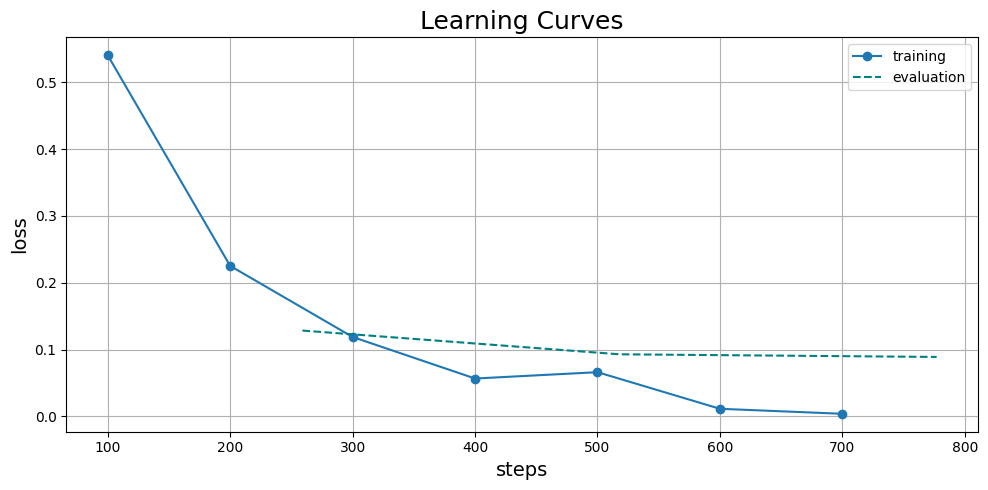

In [15]:
import matplotlib.pyplot as plt

# Get training steps and losses
train_loss_steps = [log["step"] for log in log_history if "loss" in log]
train_loss_values = [log["loss"] for log in log_history if "loss" in log]
eval_loss_steps = [log["step"] for log in log_history if "eval_loss" in log]
eval_loss_values = [log["eval_loss"] for log in log_history if "eval_loss" in log]

# Plot training vs eval loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss_steps, train_loss_values, label="training", color='#1f77b4', marker='o')
plt.plot(eval_loss_steps, eval_loss_values, label="evaluation", color='#008080', linestyle='--')

plt.title("Learning Curves", fontsize=18)
plt.xlabel("steps", fontsize=14)
plt.ylabel("loss", fontsize=14)

plt.tight_layout()
plt.grid(True)
plt.legend()

plt.savefig(eval_path+"/learning_curves.png", dpi=300)
plt.show()

## Evaluation Analysis

In [16]:
# Run predictions on the evaluation set
preds = trainer.predict(tokenized_dataset["eval"])

y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

In [17]:
from sklearn.metrics import classification_report

# Classification report
report = classification_report(y_true, y_pred, target_names=id2label.values())

with open(eval_path+"/classification_report.txt", "w") as f:
    f.write(report)

print(report)

                precision    recall  f1-score   support

ask_definition       0.96      0.91      0.93        93
     greetings       1.00      1.00      1.00         3
     make_joke       1.00      1.00      1.00        25
    play_audio       1.00      0.99      0.99       493
  search_query       0.96      0.99      0.98       306

      accuracy                           0.98       920
     macro avg       0.98      0.98      0.98       920
  weighted avg       0.98      0.98      0.98       920



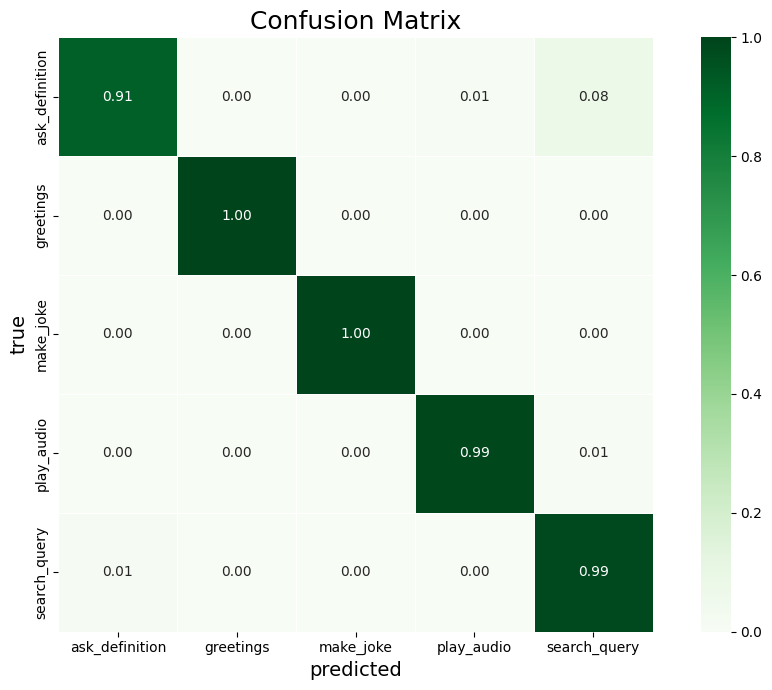

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix

def plot_confusion_matrix(
    y_true,
    y_pred,
    labels=None,
    normalize=False,
    figsize=(10, 7),
    cmap="Greens"
):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(labels)), normalize='true' if normalize else None)

    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap=cmap, 
                xticklabels=labels, yticklabels=labels, linewidths=0.5, square=True)

    plt.title("Confusion Matrix", fontsize=18)
    plt.xlabel("predicted", fontsize=14)
    plt.ylabel("true", fontsize=14)
    plt.tight_layout()

    plt.savefig(eval_path+"/confusion_matrix.png", dpi=300)
    plt.show()

labels = list(model.config.id2label.values())
plot_confusion_matrix(y_true, y_pred, labels=labels, normalize=True)

---